In [1]:
# reading tsv.gz file to dataframe 

import pandas as pd
import gzip
import matplotlib.pyplot as plt

PATH_TRAIN = '/media/alvarinho/dados/Estudos/traducao-rede-neural/data/en-pt_BR.txt'

In [6]:
from itertools import islice

n = 50_000_000  # number of lines to read

pairs = []

with open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.en", encoding="utf-8") as f_en, \
     open(f"{PATH_TRAIN}/OpenSubtitles.en-pt_BR.pt_BR", encoding="utf-8") as f_pt:

    for en, pt in islice(zip(f_en, f_pt), n):
        if en.strip() and len(en.strip()) > 100:
            pairs.append((en.strip(), pt.strip()))

In [7]:
# exemplo
for en, pt in pairs[:5]:
    print("EN:", en.strip())
    print("PT:", pt.strip())
    print()

EN: Director Mueller just assigned us a major case number. Investigation''s  officially been dubbed Amerithrax. Whoever sent these  letters got their Anthrax from an American lab.
PT: o diretor mueller acaba de nomear nos um número de caso principal, investigações foi oficialmente dublado amerithrax, quemosenviou cartas receberam antraz de um laboratório americano, nós não estaríamos aqui se nós não tinha provas nos conduzindo de volta para usamriid,

EN: Bruce Ivins is our top anthrax man. Then I wanna talk to him. They''re treating us like we''re the enemy.
PT: bruce ivins é o nosso melhor homem com antraz, então eu quero falar com ele, eles estão nos tratando como se fôssemos o inimigo, nós somos os heróis, a entrada tem que ser através do complexo de seu herói,

EN: I know most Americans aren''t paying attention, but you guys had signs that 9/11 was gonna happen. And now you can''t figure  out who sent these letters. So instead you are harassing hard working patriots like me.
PT: e

In [93]:
df = pd.DataFrame(pairs, columns=["en", "pt"])

In [94]:
df = df.loc[
    (df['en'].str.len() > 100)
]

In [95]:
df = df.drop_duplicates(subset='en')

In [96]:
df.info()

<class 'pandas.DataFrame'>
Index: 1288330 entries, 0 to 1300198
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   en      1288330 non-null  str  
 1   pt      1288330 non-null  str  
dtypes: str(2)
memory usage: 337.3 MB


In [97]:
df.head(10)

,en,pt
0,Director Mueller just assigned us a major case...,o diretor mueller acaba de nomear nos um númer...
1,Bruce Ivins is our top anthrax man. Then I wan...,"bruce ivins é o nosso melhor homem com antraz,..."
2,I know most Americans aren''t paying attention...,eu conheço a maioria dos americanos não estão ...
3,I had obsessive behaviors linked to sororitie...,tiveobsessivo comportamentos ligados a irmanda...
4,FBI agents searched the home of Steven Hatfil...,:fbi agentes vasculharam a casa de steven hat...
5,Just crushing some chlorpromazine pills for Mr...,só esmagando algumas pílulas de clorpromazina ...
6,"Press the other side and there, it''s called a...","pressione o outro lado e ali, é chamado de do ..."
7,The map we found at Hatfill''s spans acres of ...,o mapa que encontramos nos vãos de hatfill hec...
8,"Come on, the guy wrote a book about a biologic...","vamos lá, o cara escreveu um livro sobre um bi..."
9,"Then again, maybe he''s like any of us, made a...",fez alguns questionáveis julgamento chama na v...


In [98]:
examples = df.sample(10)

for _, row in examples.iterrows():
    print("EN:", row['en'])
    print("PT:", row['pt'])
    print()

EN: No, no, she just said that she'd get the first train back to Bristol, and then they'd go on together.
PT: - Não, não. Só disse que regressaria no primeiro trem para Bristol e que depois seguiriam juntas.

EN: But that doesn't explain Why diabetic willis lasted for hours with Andromeda And an alcoholic man and a colicky baby
PT: - Mas isto não explica... por que o diabético Willis durou horas com Andrômeda, e um alcoólatra e um bebê com cólicas... continuam intocados.

EN: Americans have been advertised that longest, and they now each consumed twice as much energy as an European,
PT: Os EUA são alvo da mídia há tempos, e hoje consomem duas vezes mais eletricidade que os europeus.

EN: I swear to you, on our children, that my midlife crisis problems will no longer intrude on you any more.
PT: Juro, pelos nossos filhos... que minha crise de meia-idade... não vai fazer mais mal para você.

EN: But don't worry, fear will come later, when the pliers will bite you right there, where you n

In [99]:
df['en_length'] = df['en'].str.len()
df['pt_length'] = df['pt'].str.len()

In [100]:
df['en_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.288330e+06
mean     1.302354e+02
std      3.201081e+01
min      1.010000e+02
25%      1.090000e+02
50%      1.200000e+02
75%      1.410000e+02
90%      1.700000e+02
95%      1.940000e+02
99%      2.440000e+02
max      3.269000e+03
Name: en_length, dtype: float64

In [101]:
df = df[df['en_length'] <= df['en_length'].quantile(0.90)]

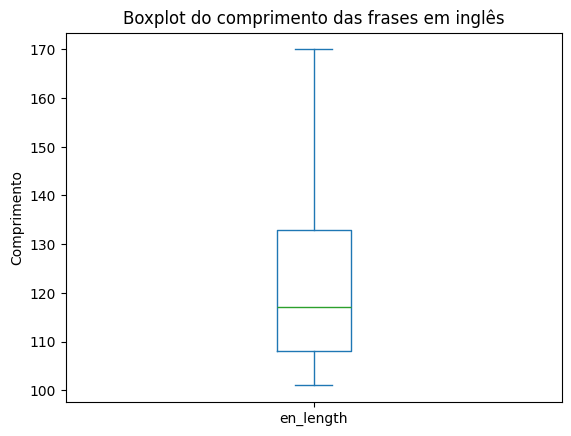

In [102]:
df['en_length'].plot.box()
plt.title("Boxplot do comprimento das frases em inglês")
plt.ylabel("Comprimento")
plt.show()

In [103]:
len(df)

1159930

In [104]:
df = df[
    (df['pt_length'] >= (df['en_length'] * 0.90)) &
    (df['pt_length'] <= (df['en_length'] * 1.1))
    ]

In [105]:
len(df)

495123

In [106]:
df

,en,pt,en_length,pt_length
3,I had obsessive behaviors linked to sororitie...,tiveobsessivo comportamentos ligados a irmanda...,143,137
12,Seemed to avoid the Seventh Circle of Hell for...,parecia evitar o sétimo círculo do inferno por...,102,109
20,Yes. We finally developed the test that will d...,"sim, finalmente desenvolvemos o teste que irá ...",156,158
24,"You know, it sounds you''ve got something weig...","você sabe, parece você tem algo pesando em seu...",126,121
31,I don''t understand why the FBI''s hounding us...,não entendo por que o fbi está nos perseguindo...,118,122
...,...,...,...,...
1300155,"According to our Agency friends, most of the r...","De acordo com nossos amigos da CIA, a maioria ...",102,111
1300170,"My brother was obsessed with the game, even th...","Meu irmão era obcecado por beisebol, mas ele s...",116,112
1300173,I'll establish a radiological profile and an o...,Estabelecerei um perfil radiológico e um padrã...,123,113
1300175,"And I don't feel they're safe with you here, w...",E não acho que estejam seguras com você aqui. ...,111,103


In [107]:
df['en'] = df['en'].str.capitalize()
df['pt'] = df['pt'].str.capitalize()

In [108]:
df['en'] = df.apply(lambda x: x['en'][:-1] if x['en'][-1] in [','] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt'][:-1] if x['pt'][-1] in [','] else x['pt'], axis=1)

In [109]:
df['en'] = df.apply(lambda x: x['en']+'.' if x['en'][-1] not in ['.', '!', '?'] else x['en'], axis=1)
df['pt'] = df.apply(lambda x: x['pt']+'.' if x['pt'][-1] not in ['.', '!', '?'] else x['pt'], axis=1)

In [ ]:
df['en_max_len_word'] = df['en'].apply(lambda x: max(len(word) for word in x.split()))
df['pt_max_len_word'] = df['pt'].apply(lambda x: max(len(word) for word in x.split()))

In [115]:
df.en_max_len_word.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    495123.000000
mean         10.261814
std           2.247252
min           3.000000
25%           9.000000
50%          10.000000
75%          11.000000
90%          13.000000
95%          14.000000
99%          17.000000
max          51.000000
Name: en_max_len_word, dtype: float64

In [122]:
df.loc[df['en_max_len_word'] > 20].en.values[100]

'The conventions of an ordered society... have made us lose what freud calls our urmenschgefuhnaturlichkeit.'

In [124]:
df = df.loc[df['en_max_len_word'] <= df['en_max_len_word'].quantile(0.9)]
df = df.loc[df['pt_max_len_word'] <= df['pt_max_len_word'].quantile(0.9)]

In [ ]:
df = df[len(df['pt'].str.split())]

In [135]:
df = df.reset_index(drop=True)

In [141]:
index = int(df.sample(1).index[0])
print(df.en.values[index])
print(df.pt.values[index])

And i like smart girls... because they can understand the benefits to be derived... from cooperating at my little parties.
E gosto de garotas espertas, porque podem entender os benefícios que podem tirar cooperando com as minhas festinhas.


In [142]:
train_df = df.sample(frac=0.8, random_state=42)
eval_test_df = df.drop(train_df.index)
test_df = eval_test_df.sample(frac=0.8, random_state=42)
eval_df = eval_test_df.drop(test_df.index)

In [143]:
len(eval_df)

15661

In [144]:
eval_df.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word
15,"People like your father, they won''t appreciat...","Pessoas como seu pai, eles não vão gostar de v...",133,139,10,11
27,Joseph smith himself ordered a company of dani...,Joseph smith que se mandou ele mesmo uma compa...,145,146,10,11
59,"Elizabeth, by the grace of god, queen of engla...","Elizabeth, pela graça de deus, rainha da ingla...",143,142,10,11
69,"Captain lombrico wants to question saturnino, ...","O capitão lombrico quer questionar saturnino, ...",158,150,10,12
71,"Professor croknuff, thinking of having to stud...","O professor croknuff, pensando em estudar um n...",154,157,10,11


In [145]:
train_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/train.csv', index=False)
eval_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/eval.csv', index=False)
test_df.to_csv('/media/alvarinho/dados/Estudos/traducao-rede-neural/data/test.csv', index=False)